# 5. Results

In [92]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [93]:
# Built-in
import os
import json
import datetime

# PlatoSim standard
import scipy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy import constants as c
from pathlib import Path

# PlatoSim libraries
import platosim.smbhb as smbhb
import platosim.utilities as ut
from platosim.lightcurve import LightCurve
from platosim.matplotlibrc import setup_paper
setup_paper()

from IPython.display import display, HTML
display(HTML("<style>.container {width:80% !important; }</style>"))

In [94]:
# Paths to where data is stored
path = Path(os.getenv('PLATO_WORKDIR')) / 'smbhb'
fdir = path / 'figures'
sdir = path / 'simulations/lcs'
rdir = sdir / 'reduced'
vdir = sdir / 'varsource'
udir = path / 'results'

---
## 1. Parameter variation plots
---

In [169]:
def plot_parameter_variation(files, values, parameter, unit='', 
                             fiducial=False, ofile=False):
    # Load light curves of 1h cadence
    dh1 = pd.read_feather(rdir / f'lc_spikey_{files[0]}_1h.ftr')
    dh2 = pd.read_feather(rdir / f'lc_spikey_{files[1]}_1h.ftr')
    dh3 = pd.read_feather(rdir / f'lc_spikey_{files[2]}_1h.ftr')
    dh4 = pd.read_feather(rdir / f'lc_spikey_{files[3]}_1h.ftr')
    dh_all = [dh1, dh2, dh3, dh4]
    # Load light curves of 1d cadence
    dd1 = pd.read_feather(rdir / f'lc_spikey_{files[0]}_1d.ftr')
    dd2 = pd.read_feather(rdir / f'lc_spikey_{files[1]}_1d.ftr')
    dd3 = pd.read_feather(rdir / f'lc_spikey_{files[2]}_1d.ftr')
    dd4 = pd.read_feather(rdir / f'lc_spikey_{files[3]}_1d.ftr')
    dd_all = [dd1, dd2, dd3, dd4]
    # Load variable source injected
    if fiducial:
        dv = pd.read_feather(vdir / f'varsource_spikey_fiducial_components.ftr')
        dv_all = [dv, dv, dv, dv]
    else:
        dv1 = pd.read_feather(vdir / f'varsource_spikey_{files[0]}_components.ftr')
        dv2 = pd.read_feather(vdir / f'varsource_spikey_{files[1]}_components.ftr')
        dv3 = pd.read_feather(vdir / f'varsource_spikey_{files[2]}_components.ftr')
        dv4 = pd.read_feather(vdir / f'varsource_spikey_{files[3]}_components.ftr')
        dv_all = [dv1, dv2, dv3, dv4]
    # Plot variables
    th = dh1.time
    td = dd1.time
    N = len(dh_all)
    ah, ad = 0.1, 0.3
    ch, cd, cv, cvm = 'k', 'gray', 'royalblue', 'orange'
    # Plot magnitude dependence of Spikey
    fig, ax = plt.subplots(N, 1, figsize=(8.5, 9))
    for i, x, dh, dd, dv in zip(range(N), values, dh_all, dd_all, dv_all):
        # Get proper models
        fh, fh_err = (dh.flux - 1) * 1e3, dh.flux_err * 1e3
        fd, fd_err = (dd.flux - 1) * 1e3, dd.flux_err * 1e3
        tv, fv = dv.time / 86400, (dv.flux - 1) * 1e3
        fv_model = (dv.flux_boost * dv.flux_lens - 1) * 1e3
        # Plot all
        if isinstance(x, float):
            value = f'{x:.1f}'
        else:
            value = f'{x:.0f}'
        ax[i].errorbar(th, fh, yerr=fh_err, fmt='.', c=ch, alpha=ah, zorder=1, 
                       label=parameter + r' = ' + value + unit)
        ax[i].errorbar(td, fd, yerr=fd_err, fmt='.', c=cd, alpha=ad, zorder=1)
        ax[i].plot(tv, fv, '-', c=cv, lw=0.8)
        ax[i].plot(tv, fv_model, '-', c=cvm, lw=1.5)
        # Settings
        ax[i].set_xlim(th.min(), th.max())
        ax[i].legend(loc='upper center', fontsize=15)
    # Add quarter marks
    smbhb.plot_quarter_marks(ax, th.to_numpy(), N, Q0=1)
    # Global settings
    ax[N-1].set_xlabel('Time [days]')
    fig.text(0.01, 0.5, 'Flux [ppt]', va='center', rotation='vertical')
    plt.tight_layout(h_pad=0)
    fig.subplots_adjust(hspace=0)
    # Extra for magnitude
    if fiducial == 'mag':
        ax[-1].set_ylim(-170, 170)
    # Save figure
    if ofile:
        fig.savefig(ofile, bbox_inches='tight', dpi=200)

### Plato magnitude, $\mathcal{P}$

<IPython.core.display.Javascript object>


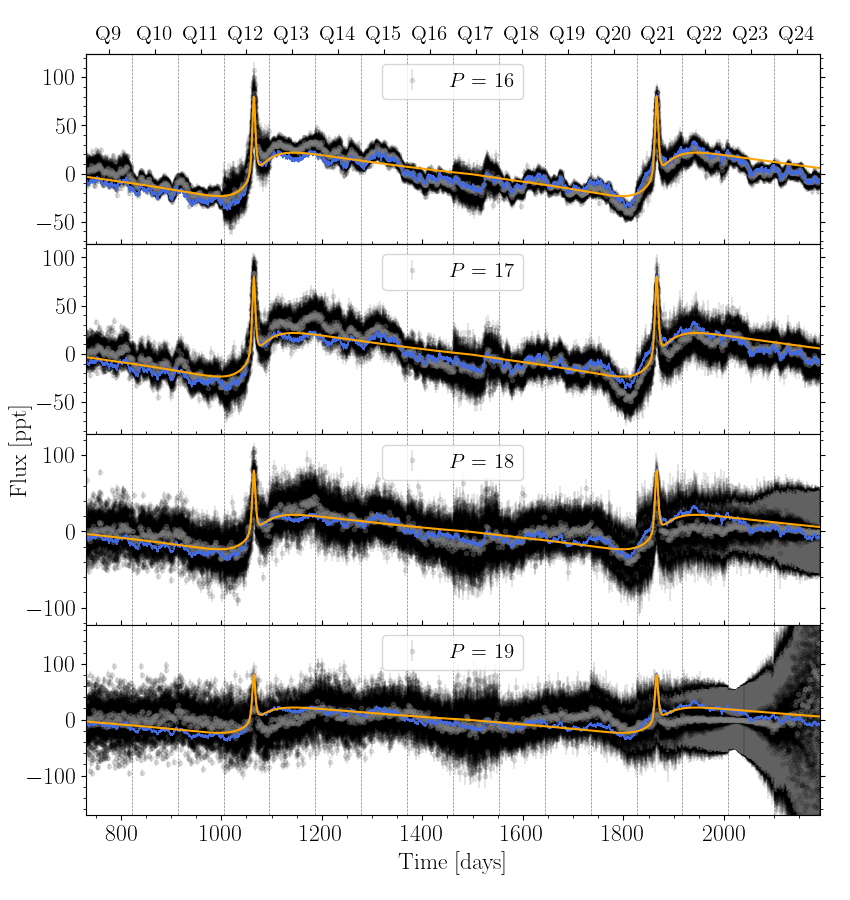

In [170]:
files = ['mag16', 'mag17', 'mag18', 'mag19']
values = [16, 17, 18, 19]
ofile = fdir / f'lc_mag.png'
plot_parameter_variation(files, values, r'$P$', fiducial='mag', ofile=ofile)

### Inclination, $i$

<IPython.core.display.Javascript object>


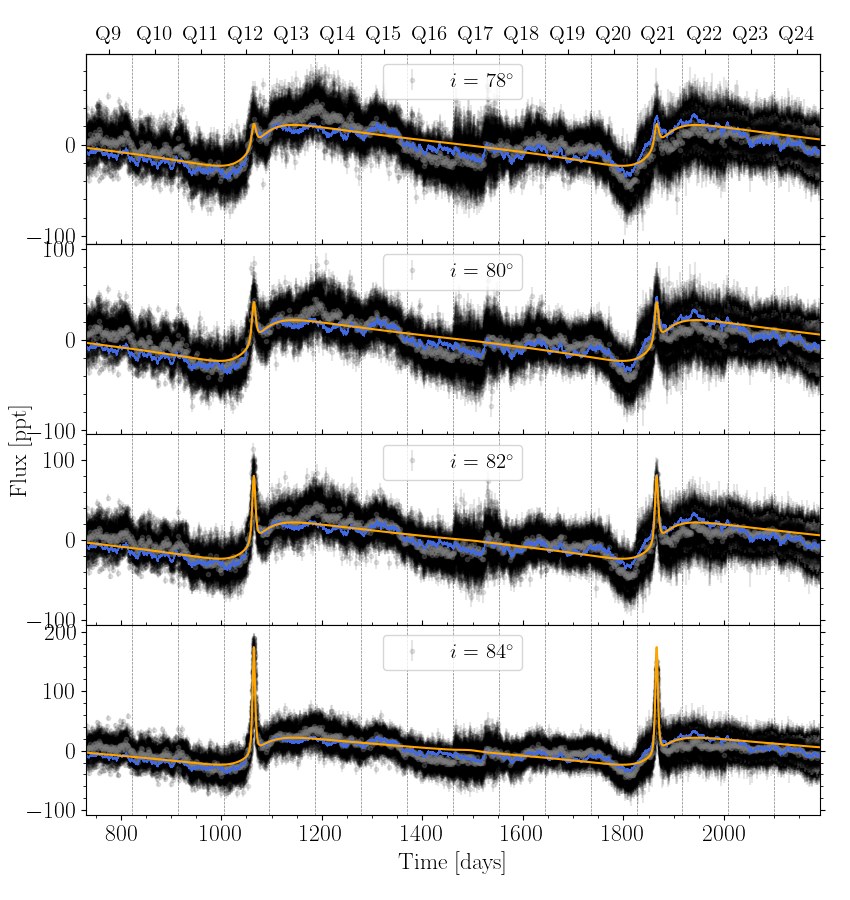

In [159]:
files = ['i78', 'i80', 'fiducial', 'i84']
values = [78, 80, 82, 84]
plot_parameter_variation(files, values, r'$i$', r'$^{\circ}$')

### Argument of periapse, $\omega$

<IPython.core.display.Javascript object>


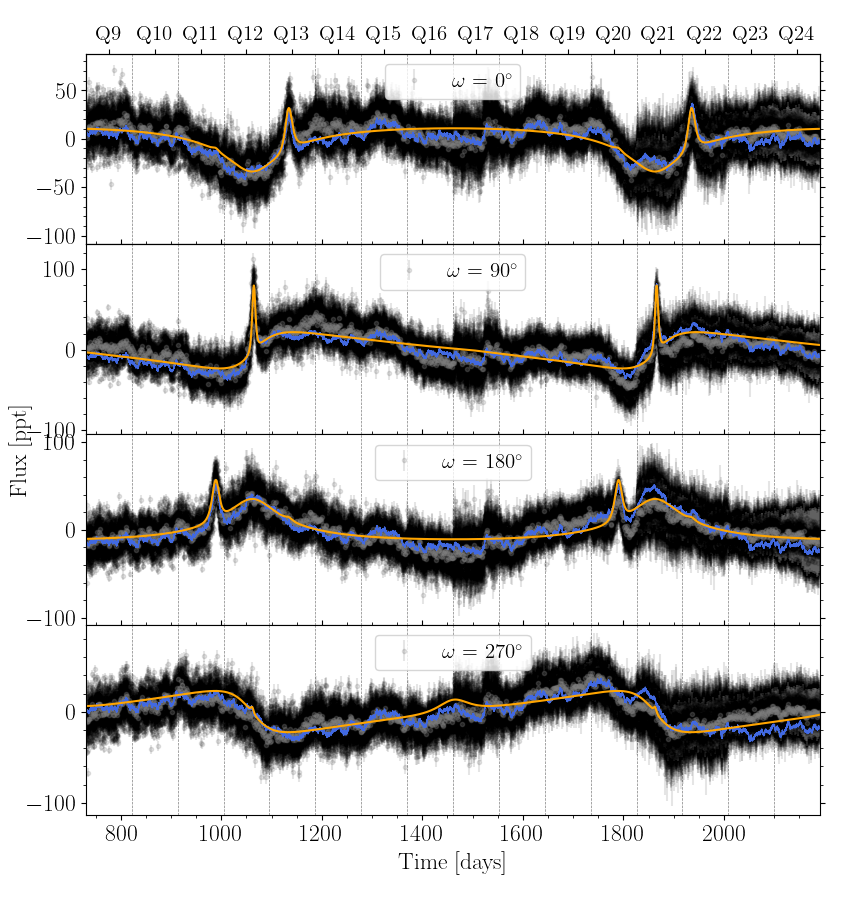

In [160]:
files = ['w000', 'fiducial', 'w180', 'w270']
values = [0, 90, 180, 270]
plot_parameter_variation(files, values, r'$\omega$',  r'$^{\circ}$')

### Eccentricity, $e$

<IPython.core.display.Javascript object>


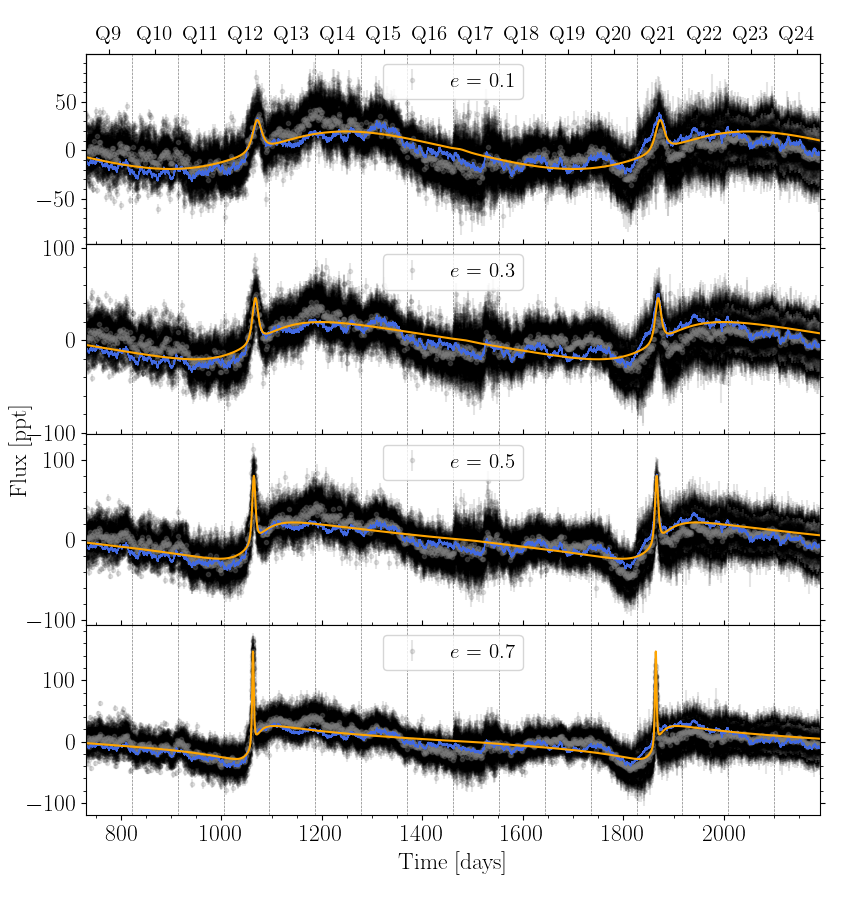

In [154]:
files = ['e01', 'e03', 'fiducial', 'e07']
values = [0.1, 0.3, 0.5, 0.7]
plot_parameter_variation(files, values, r'$e$')

### DRW amplitude,  $\text{SF}_\infty$

<IPython.core.display.Javascript object>


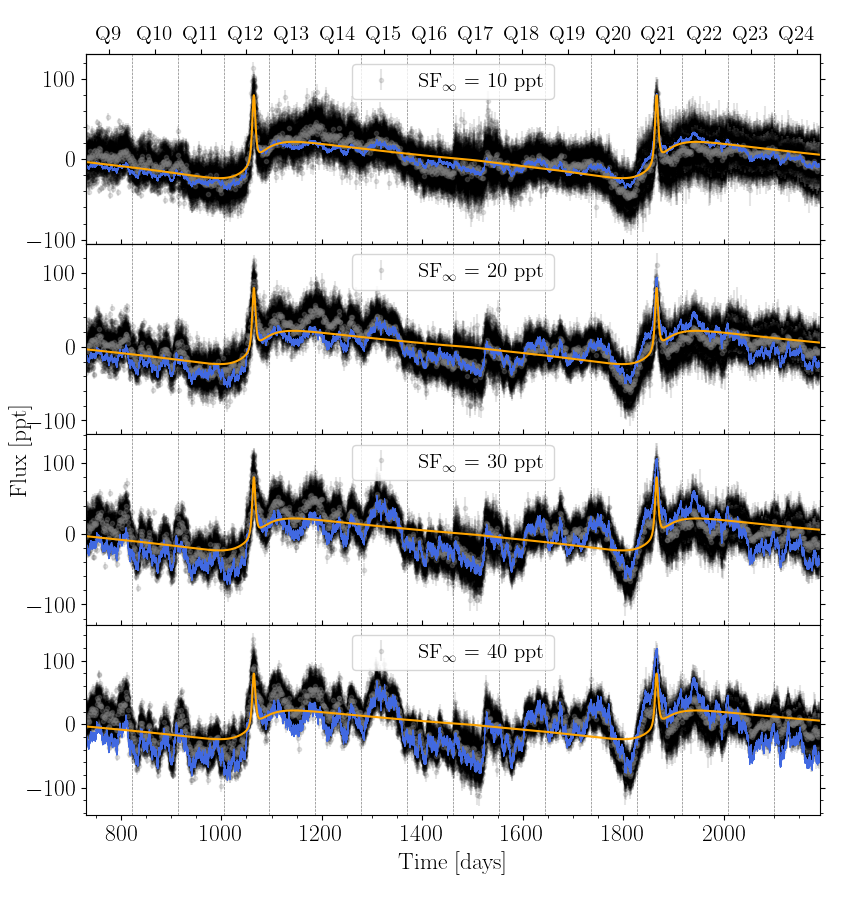

In [163]:
files = ['fiducial', 'sigma20', 'sigma30', 'sigma40']
values = [10, 20, 30, 40]
plot_parameter_variation(files, values, r'SF$_\infty$', ' ppt')

### DRW amplitude,  $\text{SF}_\infty$ ($\tau = 10$ days)

<IPython.core.display.Javascript object>


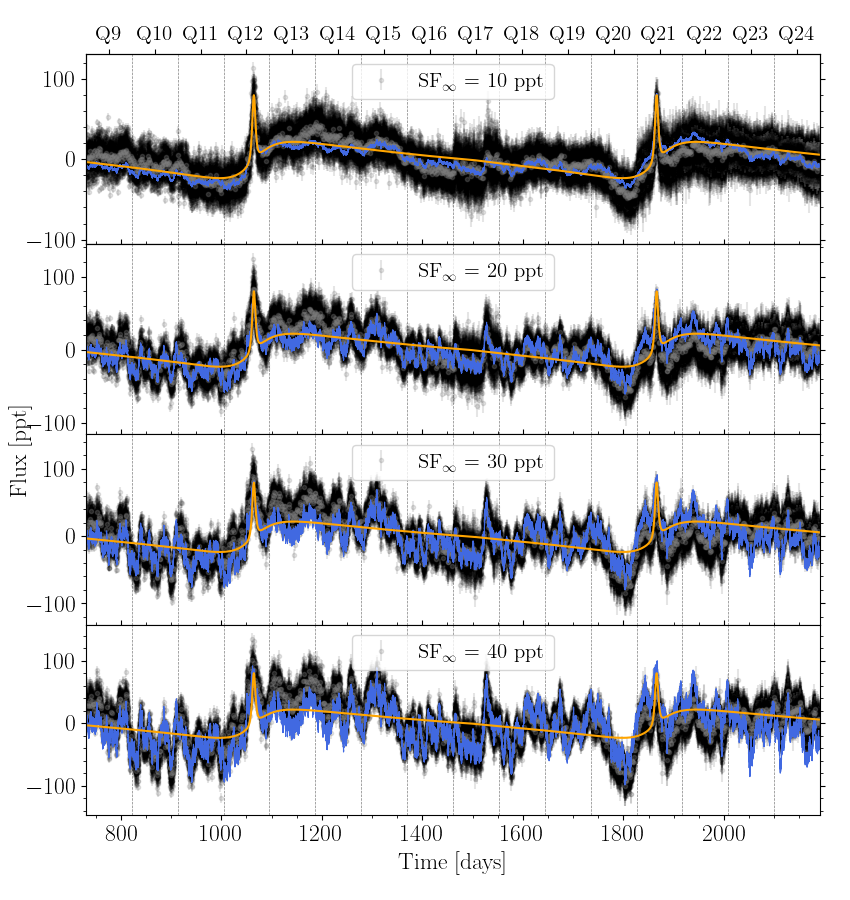

In [165]:
files = ['fiducial', 'tau10_sigma20', 'tau10_sigma30', 'tau10_sigma40']
values = [10, 20, 30, 40]
plot_parameter_variation(files, values,  r'SF$_\infty$', ' ppt')

### Plot for paper showing low signal detection 

<IPython.core.display.Javascript object>


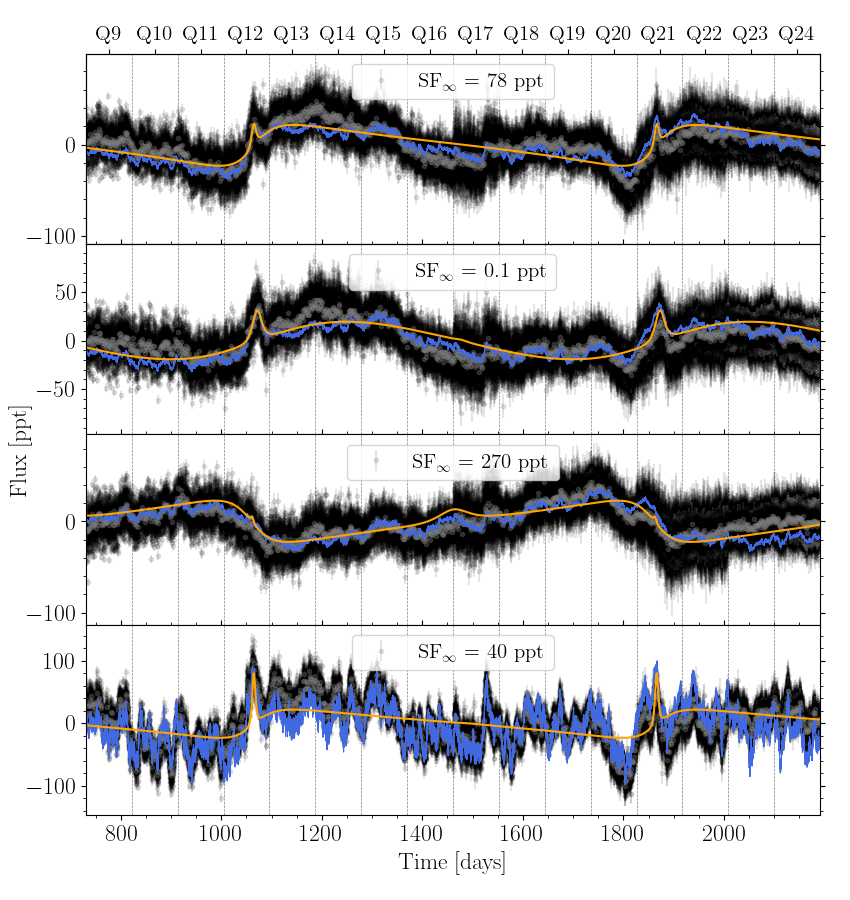

In [171]:
files = ['i78', 'e01', 'w270', 'tau10_sigma40']
values = [78, 0.1, 270, 40]
ofile = fdir / f'lc_wcs.png'
plot_parameter_variation(files, values,  r'SF$_\infty$', ' ppt', ofile=ofile)

---
## Plot model parmater recovery 
---

In [87]:
xlab = [r'$t0$', r'$P$', r'$i$', r'$e$', r'$\omega$', r'$\log M_1$', r'$\log M_2$', '$L$', r'$\alpha$']


<IPython.core.display.Javascript object>


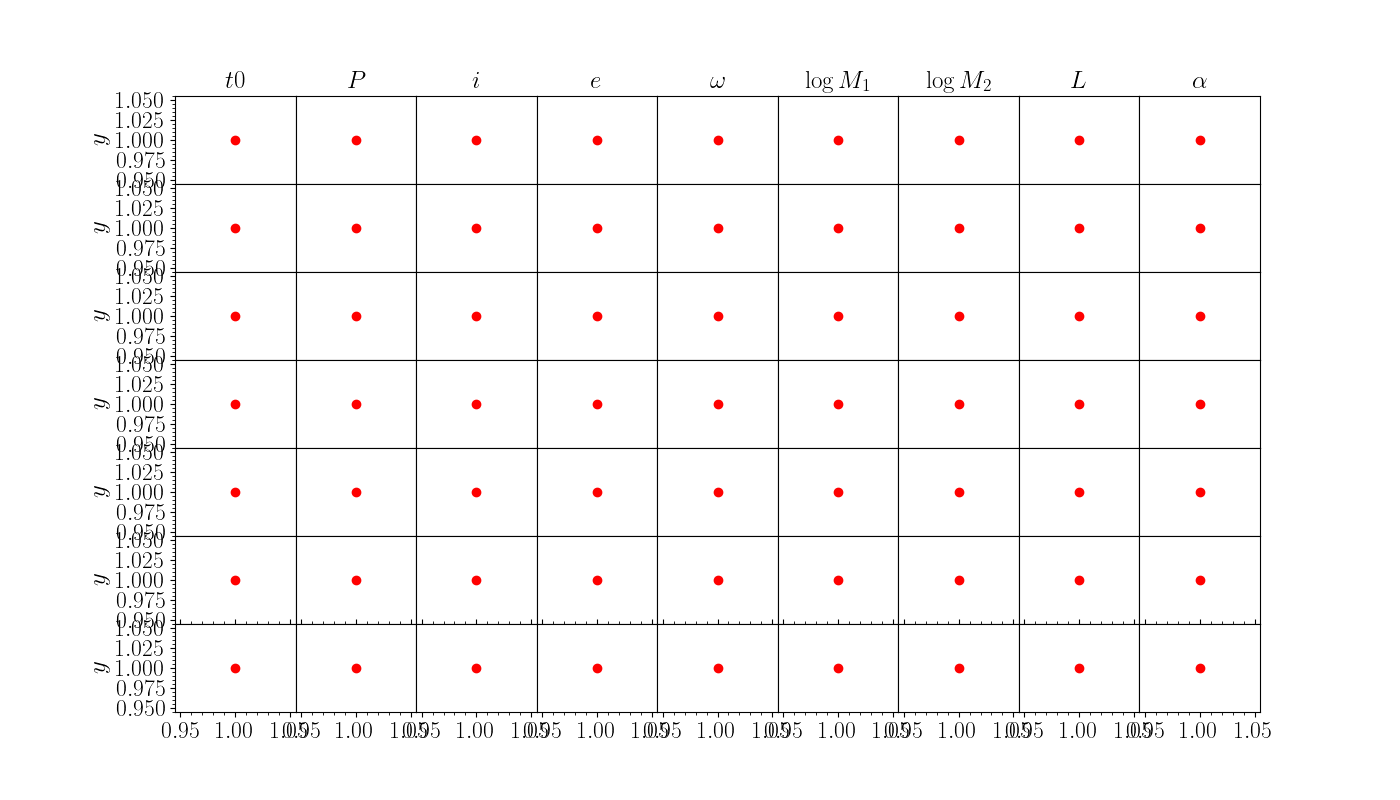

In [155]:
from matplotlib.ticker import MaxNLocator

numPlotsY = 7
numPlotsX = 9
f, ax_grid = plt.subplots(numPlotsY,numPlotsX, sharex=False, sharey=False, figsize=(14,8))

# A = np.arange(numPlotsY)+1.0
# phi = np.arange(numPlotsX)
# x = np.linspace(0,2.0,100)
fontsize = 18

for y_i in range(numPlotsY):
    for x_i in range(numPlotsX):
#         y = A[y_i]*np.sin(x*np.pi + phi[x_i])
        ax = ax_grid[y_i,x_i]
#         ax.axvline(x=0, color='r', ls='--') #plot(x,y,lw=2.0)
        ax.plot(1, 1, 'ro')
        # If left-most column:  Remove all overlapping y-ticks
        # Else:                 Remove all ticks
        if x_i == 0:
            ax.set_ylabel(r'$y$', fontsize=fontsize)
            # If top left subplot:      Remove bottom y-tick
            # If bottom left subplot:   Remove top y-tick
            # Else:                     Remove top and bottom y-ticks
            if y_i == 0:
                nbins = len(ax.get_yticklabels())
                ax.yaxis.set_major_locator(MaxNLocator(nbins=nbins,prune='lower'))
            elif y_i == numPlotsY-1:
                nbins = len(ax.get_yticklabels())
                ax.yaxis.set_major_locator(MaxNLocator(nbins=nbins,prune='upper'))
            else:
                nbins = len(ax.get_yticklabels())
                ax.yaxis.set_major_locator(MaxNLocator(nbins=nbins,prune='both'))
        else:
            ax.yaxis.set_ticks([])

        # If bottom row:    Remove all overlapping x-ticks
        # Else:             Remove all ticks
        if y_i == numPlotsY-1:
            pass
        else:
            ax.xaxis.set_ticks([])

        if y_i == 0:
            ax.set_title(xlab[x_i], fontsize=fontsize)

f.subplots_adjust(wspace=0,hspace=0)
# plt.suptitle(r'$A\cdot\sin\left(2\pi x + \phi\right)$',fontsize=18)
plt.show()